# **Práctica 4**: GANs
# Parte 1: GANs simples

Simplificación de:
https://medium.com/@mattiaspinelli/simple-generative-adversarial-network-gans-with-keras-1fe578e44a87

### Ejercicio prelab:
Lee y ejecuta el siguiente código

Importamos librerías

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Suppress info messages (already set in Colab)
import tensorflow as tf

In [2]:
import numpy as np

from keras.datasets import mnist
from keras.layers import Input, Dense, Reshape, Flatten, Dropout
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras.models import Sequential
from keras.optimizers import Adam

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['figure.figsize'] = (10, 5)
plt.style.use('ggplot')

Leemos datos MNIST

In [3]:
# Datos
(X_train, _), (_, _) = mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0 * 2.0 - 1.0
X_train = np.expand_dims(X_train, axis=3)

# Modelo

### Diseñamos modelo

Dimensiones y optimizador

In [4]:
in_shape = X_train.shape
in_shape = in_shape[1:]
optimizador_gen = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
optimizador_dis = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

I0000 00:00:1776098402.855966  258184 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14223 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Modelo del Generador

In [5]:
model_gen = Sequential(name='generator')
model_gen.add(Input((100,)))
model_gen.add(Dense(256))
model_gen.add(LeakyReLU(negative_slope=0.2))
model_gen.add(BatchNormalization(momentum=0.8))
model_gen.add(Dense(512))
model_gen.add(LeakyReLU(negative_slope=0.2))
model_gen.add(BatchNormalization(momentum=0.8))
model_gen.add(Dense(1024))
model_gen.add(LeakyReLU(negative_slope=0.2))
model_gen.add(BatchNormalization(momentum=0.8))
model_gen.add(Dense(int(np.prod(in_shape)), activation='tanh'))
model_gen.add(Reshape(in_shape))
model_gen.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

Modelo del discriminador

In [6]:
model_disc = Sequential(name='discriminator')
model_disc.add(Input(in_shape))
model_disc.add(Flatten())
model_disc.add(Dense(128))
model_disc.add(LeakyReLU(negative_slope=0.2))
model_disc.add(Dense(64))
model_disc.add(LeakyReLU(negative_slope=0.2))
model_disc.add(Dense(1, activation='sigmoid'))
model_disc.summary()
model_disc.compile(loss='binary_crossentropy', optimizer=optimizador_dis, metrics=['accuracy'])

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo combinado

In [7]:
# Important: freeze disc parameters before compiling the combined model
model_disc.trainable = False

model_gan = Sequential(name='gan')
model_gan.add(model_gen)
model_gan.add(model_disc)
model_gan.compile(loss='binary_crossentropy', optimizer=optimizador_gen)
model_gan.summary()

# Restore trainable state for discriminator
model_disc.trainable = True

Model: "gan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ generator (Sequential)          │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       108,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602,321 (6.11 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 112,385 (439.00 KB)

# Entrenamiento

In [8]:
DD_loss = []
GG_loss = []

In [9]:
# Para acelerar los experimentos seleccionamos un subset de X_train
# - Con 10000 va rápido pero con solo 50 épocas no es suficiente
# - Con 30000 las curvas de entrenamiento empiezan a tener sentido
# - Con todo (60000) va muy lento, pero es lo que habría que hacer
n_train = 20000  # len(X_train)  # <= para el conjunto completo

# Parámetros del entrenamiento
epochs = 100
batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(X_train).\
    shuffle(len(X_train), reshuffle_each_iteration=True).batch(batch_size)

# Bucle entrenamiento
pb = tqdm(range(epochs), desc="Training")
for epoch in pb:
    g_loss = 0
    d_loss = 0
    d_accr = 0
    for x_real in dataset.take(n_train // batch_size):  # take retrieves # of batches
        bs = x_real.shape[0]  # current batch size

        ## Entrenamos discriminador
        # Imágenes sintéticas
        gen_noise = tf.random.normal((bs, 100))
        x_fake = model_gen(gen_noise)
        # Combinamos imágenes reales y sintéticas
        xx = tf.concat((x_real, x_fake), axis=0)
        yy = tf.concat((tf.ones((bs, 1)), tf.zeros((bs, 1))), axis=0)
        # Entrenamos discriminador
        model_disc.trainable = True
        d_metrics = model_disc.train_on_batch(xx, yy)
        d_loss += d_metrics[0]
        d_accr += d_metrics[1]

        ## Entrenamos generador
        model_disc.trainable = False
        noise = tf.random.normal((2*bs, 100))
        y_target = tf.ones((2*bs, 1))
        g_loss += model_gan.train_on_batch(noise, y_target)

    d_loss /= (n_train // batch_size)  # len(dataset)  # retorna el numero de lotes
    d_accr /= (n_train // batch_size)  # len(dataset)
    g_loss /= (n_train // batch_size)  # len(dataset)

    ## Evolución entrenamiento
    # if (epoch+1) % 10 == 0:
    #     tqdm.write(  # print(
    #         'Epoch: %5d, gen. loss: %.6f, disc. loss: %.6f, disc. acc: %.4f' %
    #         (epoch+1, g_loss, d_loss, d_accr))

    pb.set_description(
        f"Training gen. loss {g_loss:.6f}, disc. loss {d_loss:.6f} disc. acc: {d_accr:.4f}")

    DD_loss.append(d_loss)
    GG_loss.append(g_loss)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

I0000 00:00:1776098405.043780  258184 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Curvas de aprendizaje

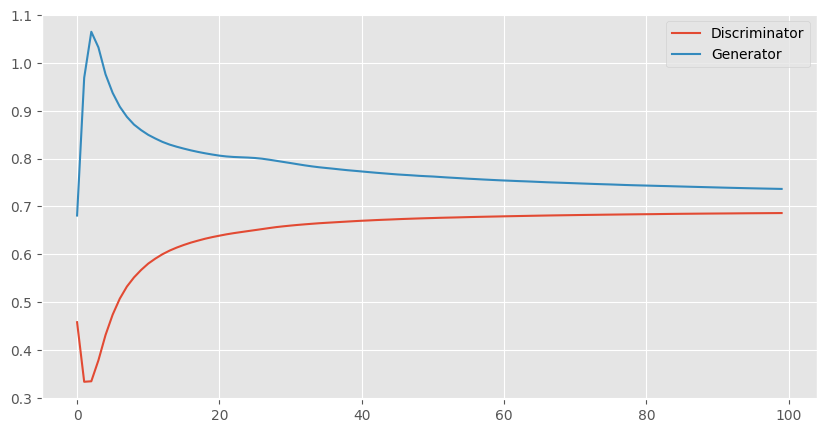

In [10]:
plt.plot(DD_loss, label='Discriminator')
plt.plot(GG_loss, label='Generator')
plt.legend()
plt.show()

# Generar datos

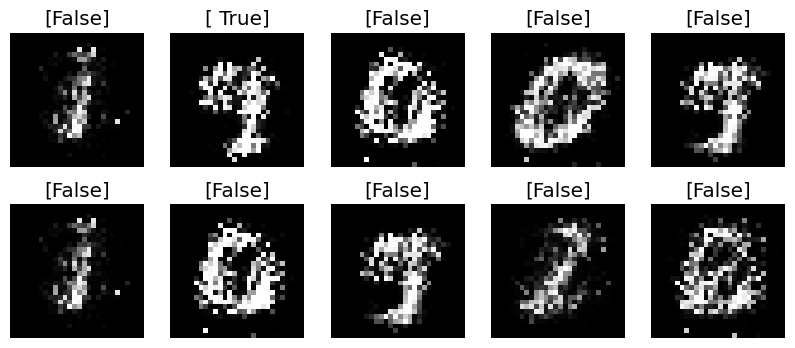

In [11]:
# Generamos imágenes sintéticas
gen_noise = np.random.normal(0, 1, (10, 100))
synthetic_images = model_gen(gen_noise)
# disc_prediction = np.round(model_disc(synthetic_images), 4)
disc_prediction = model_disc(synthetic_images).numpy() > 0.5

# Mostramos
half_len = len(synthetic_images) // 2
for i in range(half_len):
    plt.subplot(2, half_len, i+1)
    plt.imshow(synthetic_images[i], cmap='gray')
    plt.title(str(disc_prediction[i]))
    plt.axis('off')
    plt.subplot(2, half_len, half_len+i+1)
    plt.imshow(synthetic_images[2*i], cmap='gray')
    plt.title(str(disc_prediction[2*i]))
    plt.axis('off')
plt.subplots_adjust(hspace=-0.2)
plt.show()

## Imágenes reales para comparar

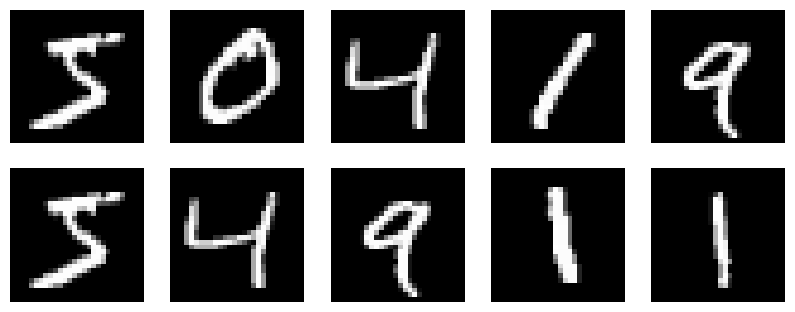

In [12]:
half_len = 5
for i in range(half_len):
    plt.subplot(2, half_len, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2, half_len, half_len+i+1)
    plt.imshow(X_train[2*i], cmap='gray')
    plt.axis('off')
plt.subplots_adjust(hspace=-0.3)
plt.show()

# Ejercicios

### Ejercicio 1:
Modifica el código para que use el dataset CIFAR 10 en lugar del MNIST.

Model: "generator_cifar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3072)           │     3,148,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,838,720 (14.64 MB)

 Trainable params: 3,835,136 (14.63 MB)

 Non-trainable params: 3,584 (14.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,961 (6.50 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

Training CIFAR-10 GAN:   0%|          | 0/50 [00:00<?, ?it/s]

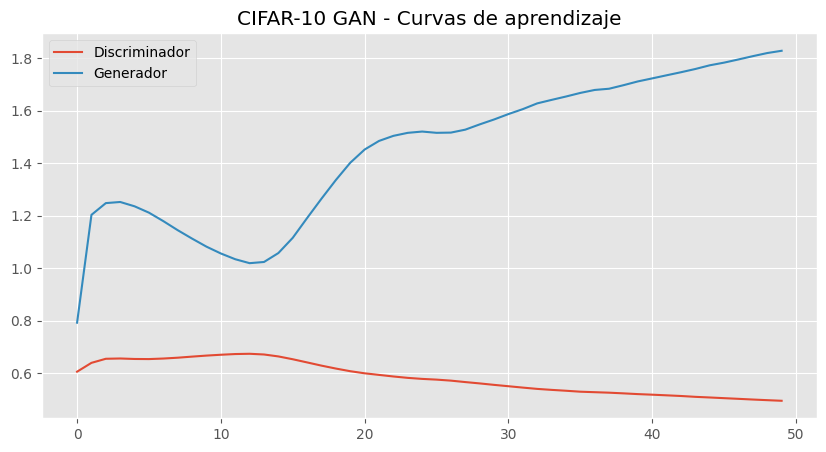

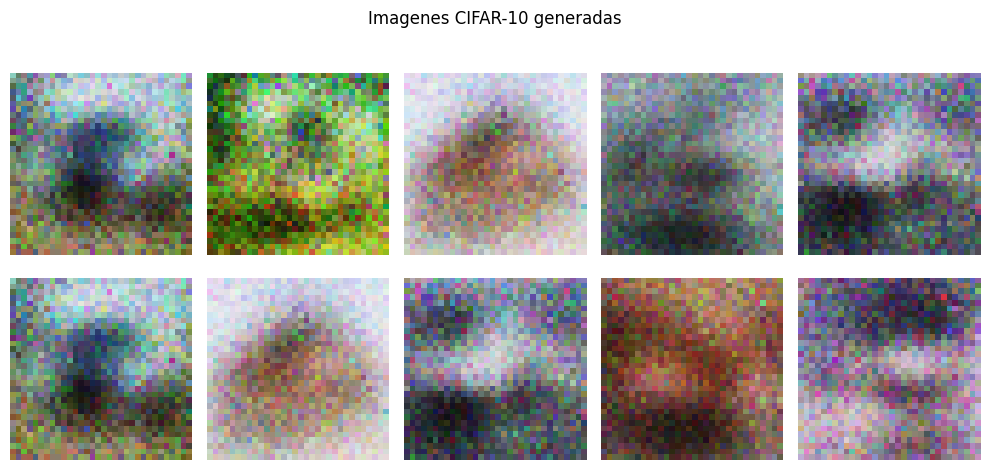

In [13]:
# Ejercicio 1: CIFAR-10 en lugar de MNIST
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
import tensorflow as tf
import numpy as np
from keras.datasets import cifar10
from keras.layers import Input, Dense, Reshape, Flatten, BatchNormalization, LeakyReLU
from keras.models import Sequential
from keras.optimizers import Adam
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Datos CIFAR-10 ---
(X_train_c, _), (_, _) = cifar10.load_data()
X_train_c = X_train_c.astype(np.float32) / 255.0 * 2.0 - 1.0  # normalizar a [-1, 1]
in_shape_c = X_train_c.shape[1:]  # (32, 32, 3)
latent_dim = 100

# --- Optimizadores ---
opt_gen_c = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)
opt_dis_c = Adam(learning_rate=2e-4, beta_1=0.5, weight_decay=8e-8)

# --- Generador ---
model_gen_c = Sequential(name='generator_cifar')
model_gen_c.add(Input((latent_dim,)))
model_gen_c.add(Dense(256));  model_gen_c.add(LeakyReLU(negative_slope=0.2)); model_gen_c.add(BatchNormalization(momentum=0.8))
model_gen_c.add(Dense(512));  model_gen_c.add(LeakyReLU(negative_slope=0.2)); model_gen_c.add(BatchNormalization(momentum=0.8))
model_gen_c.add(Dense(1024)); model_gen_c.add(LeakyReLU(negative_slope=0.2)); model_gen_c.add(BatchNormalization(momentum=0.8))
model_gen_c.add(Dense(int(np.prod(in_shape_c)), activation='tanh'))
model_gen_c.add(Reshape(in_shape_c))
model_gen_c.summary()

# --- Discriminador (mas ancho para manejar 32x32x3) ---
model_disc_c = Sequential(name='discriminator_cifar')
model_disc_c.add(Input(in_shape_c))
model_disc_c.add(Flatten())
model_disc_c.add(Dense(512));  model_disc_c.add(LeakyReLU(negative_slope=0.2))
model_disc_c.add(Dense(256));  model_disc_c.add(LeakyReLU(negative_slope=0.2))
model_disc_c.add(Dense(1, activation='sigmoid'))
model_disc_c.summary()
model_disc_c.compile(loss='binary_crossentropy', optimizer=opt_dis_c, metrics=['accuracy'])

# --- Modelo combinado ---
model_disc_c.trainable = False
model_gan_c = Sequential(name='gan_cifar')
model_gan_c.add(model_gen_c); model_gan_c.add(model_disc_c)
model_gan_c.compile(loss='binary_crossentropy', optimizer=opt_gen_c)
model_disc_c.trainable = True

# --- Entrenamiento ---
DD_loss_c, GG_loss_c = [], []
n_train_c = 10000; epochs_c = 50; batch_size_c = 128
dataset_c = tf.data.Dataset.from_tensor_slices(X_train_c).\
    shuffle(len(X_train_c), reshuffle_each_iteration=True).batch(batch_size_c)
pb = tqdm(range(epochs_c), desc='Training CIFAR-10 GAN')
for epoch in pb:
    g_loss, d_loss, d_acc = 0.0, 0.0, 0.0
    for x_real in dataset_c.take(n_train_c // batch_size_c):
        bs = x_real.shape[0]
        x_fake = model_gen_c(tf.random.normal((bs, latent_dim)))
        xx = tf.concat([x_real, x_fake], axis=0)
        yy = tf.concat([tf.ones((bs, 1)), tf.zeros((bs, 1))], axis=0)
        model_disc_c.trainable = True
        dm = model_disc_c.train_on_batch(xx, yy)
        d_loss += dm[0]; d_acc += dm[1]
        model_disc_c.trainable = False
        g_loss += model_gan_c.train_on_batch(tf.random.normal((2*bs, latent_dim)), tf.ones((2*bs, 1)))
    nb_c = n_train_c // batch_size_c
    d_loss /= nb_c; d_acc /= nb_c; g_loss /= nb_c
    pb.set_description(f'CIFAR gen={g_loss:.4f} disc={d_loss:.4f} acc={d_acc:.4f}')
    DD_loss_c.append(d_loss); GG_loss_c.append(g_loss)

plt.plot(DD_loss_c, label='Discriminador'); plt.plot(GG_loss_c, label='Generador')
plt.legend(); plt.title('CIFAR-10 GAN - Curvas de aprendizaje'); plt.show()

# Visualizar imagenes generadas
gen_noise_c = np.random.normal(0, 1, (10, latent_dim))
synthetic_c = model_gen_c(gen_noise_c).numpy()
synthetic_c = (synthetic_c + 1.0) / 2.0  # denormalizar a [0,1]
for i in range(5):
    plt.subplot(2, 5, i+1);   plt.imshow(synthetic_c[i]);   plt.axis('off')
    plt.subplot(2, 5, 5+i+1); plt.imshow(synthetic_c[2*i]); plt.axis('off')
plt.suptitle('Imagenes CIFAR-10 generadas'); plt.tight_layout(); plt.show()


### Ejercicio 2:
Modifica el código para incluir la generación de las etiquetas.

Model: "cgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 110)       │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256)       │     28,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 256)       │          0 │ dense_14[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ leaky_re_lu_10[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 512)       │          0 │ dense_15[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_11[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 1024)      │          0 │ dense_16[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_12[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 784)       │    803,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,496,080 (5.71 MB)

 Trainable params: 1,492,496 (5.69 MB)

 Non-trainable params: 3,584 (14.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 794)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 512)       │    407,040 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 512)       │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │    131,328 │ leaky_re_lu_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 256)       │          0 │ dense_19[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1)         │        257 │ leaky_re_lu_14[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 538,625 (2.05 MB)

 Trainable params: 538,625 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Training cGAN:   0%|          | 0/100 [00:00<?, ?it/s]

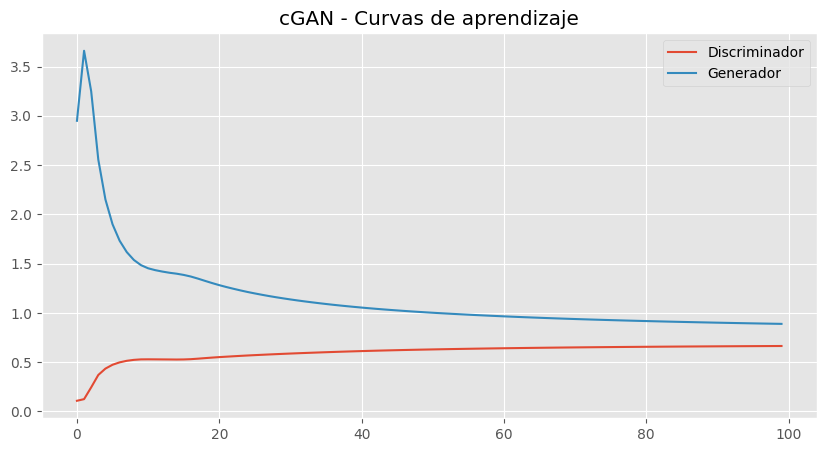

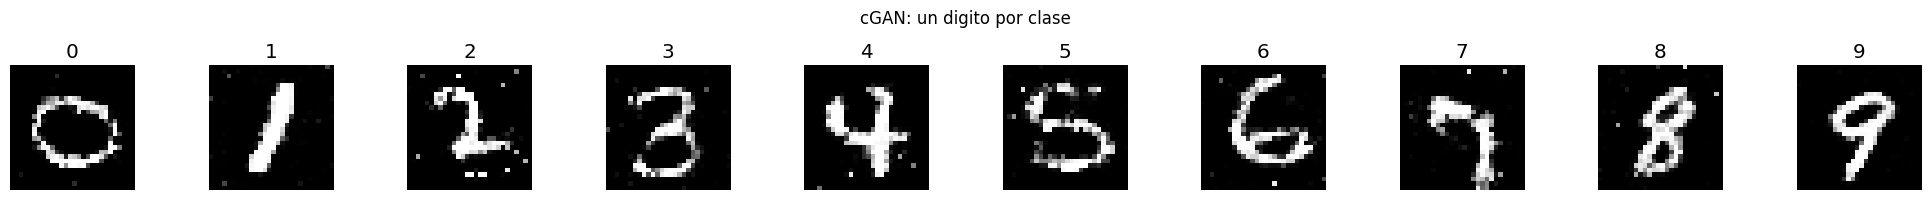

In [14]:
# Ejercicio 2: Generar con etiquetas - GAN Condicional (cGAN) sobre MNIST
from keras.datasets import mnist
from keras.layers import Input, Dense, Reshape, Flatten, BatchNormalization, LeakyReLU, Concatenate
from keras.models import Model
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Parametros ---
latent_cgan = 100; num_classes = 10
img_shape_cg = (28, 28, 1); img_flat_cg = int(28*28*1)

# --- Datos ---
(X_tr_cg, y_tr_cg), (_, _) = mnist.load_data()
X_tr_cg = X_tr_cg.astype(np.float32) / 255.0 * 2.0 - 1.0
X_tr_cg = np.expand_dims(X_tr_cg, -1)
y_onehot = np.eye(num_classes)[y_tr_cg]  # (60000, 10)

# --- Generador condicional ---
noise_in   = Input(shape=(latent_cgan,))
label_in_g = Input(shape=(num_classes,))
x_g = Concatenate()([noise_in, label_in_g])
x_g = Dense(256)(x_g);  x_g = LeakyReLU(0.2)(x_g); x_g = BatchNormalization(momentum=0.8)(x_g)
x_g = Dense(512)(x_g);  x_g = LeakyReLU(0.2)(x_g); x_g = BatchNormalization(momentum=0.8)(x_g)
x_g = Dense(1024)(x_g); x_g = LeakyReLU(0.2)(x_g); x_g = BatchNormalization(momentum=0.8)(x_g)
x_g = Dense(img_flat_cg, activation='tanh')(x_g)
img_out = Reshape(img_shape_cg)(x_g)
cgen = Model([noise_in, label_in_g], img_out, name='cgan_generator')
cgen.summary()

# --- Discriminador condicional ---
img_in    = Input(shape=img_shape_cg)
label_in_d = Input(shape=(num_classes,))
x_d = Flatten()(img_in)
x_d = Concatenate()([x_d, label_in_d])
x_d = Dense(512)(x_d); x_d = LeakyReLU(0.2)(x_d)
x_d = Dense(256)(x_d); x_d = LeakyReLU(0.2)(x_d)
validity = Dense(1, activation='sigmoid')(x_d)
cdisc = Model([img_in, label_in_d], validity, name='cgan_discriminator')
cdisc.summary()
cdisc.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5), metrics=['accuracy'])

# --- Modelo combinado ---
cdisc.trainable = False
noise_comb = Input(shape=(latent_cgan,))
label_comb = Input(shape=(num_classes,))
cgan_model = Model([noise_comb, label_comb],
                   cdisc([cgen([noise_comb, label_comb]), label_comb]),
                   name='cgan_combined')
cgan_model.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5))
cdisc.trainable = True

# --- Entrenamiento ---
n_tr_cg = 20000; ep_cg = 100; bs_cg = 128
DD_cg, GG_cg = [], []
pb = tqdm(range(ep_cg), desc='Training cGAN')
for epoch in pb:
    g_l, d_l, d_a = 0.0, 0.0, 0.0
    n_b = n_tr_cg // bs_cg
    for _ in range(n_b):
        idx = np.random.choice(len(X_tr_cg), bs_cg, replace=False)
        imgs_real = X_tr_cg[idx]; labels_real = y_onehot[idx]
        fake_labels = np.eye(num_classes)[np.random.randint(0, num_classes, bs_cg)]
        imgs_fake = cgen.predict([np.random.normal(0,1,(bs_cg, latent_cgan)), fake_labels], verbose=0)
        cdisc.trainable = True
        dr = cdisc.train_on_batch([imgs_real, labels_real], np.ones((bs_cg,1)))
        df = cdisc.train_on_batch([imgs_fake, fake_labels], np.zeros((bs_cg,1)))
        d_l += 0.5*(dr[0]+df[0]); d_a += 0.5*(dr[1]+df[1])
        cdisc.trainable = False
        gen_lab = np.eye(num_classes)[np.random.randint(0, num_classes, bs_cg)]
        g_l += cgan_model.train_on_batch(
            [np.random.normal(0,1,(bs_cg, latent_cgan)), gen_lab], np.ones((bs_cg,1)))
    d_l /= n_b; d_a /= n_b; g_l /= n_b
    pb.set_description(f'cGAN gen={g_l:.4f} disc={d_l:.4f} acc={d_a:.4f}')
    DD_cg.append(d_l); GG_cg.append(g_l)

plt.plot(DD_cg, label='Discriminador'); plt.plot(GG_cg, label='Generador')
plt.legend(); plt.title('cGAN - Curvas de aprendizaje'); plt.show()

# Visualizar: un digito por clase
noise_vis = np.random.normal(0, 1, (num_classes, latent_cgan))
gen_vis = cgen.predict([noise_vis, np.eye(num_classes)], verbose=0)
gen_vis = (gen_vis + 1.0) / 2.0
fig, axes = plt.subplots(1, num_classes, figsize=(20, 2))
for i in range(num_classes):
    axes[i].imshow(gen_vis[i,:,:,0], cmap='gray'); axes[i].set_title(str(i)); axes[i].axis('off')
plt.suptitle('cGAN: un digito por clase'); plt.tight_layout(); plt.show()


### Ejercicio 3:
Modifica el código para que use capas convolucionales en lugar de densas (en la medida de lo posible).

Model: "dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 798,593 (3.05 MB)

 Trainable params: 798,145 (3.04 MB)

 Non-trainable params: 448 (1.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,945 (386.50 KB)

 Trainable params: 98,945 (386.50 KB)

 Non-trainable params: 0 (0.00 B)

Training DCGAN:   0%|          | 0/100 [00:00<?, ?it/s]

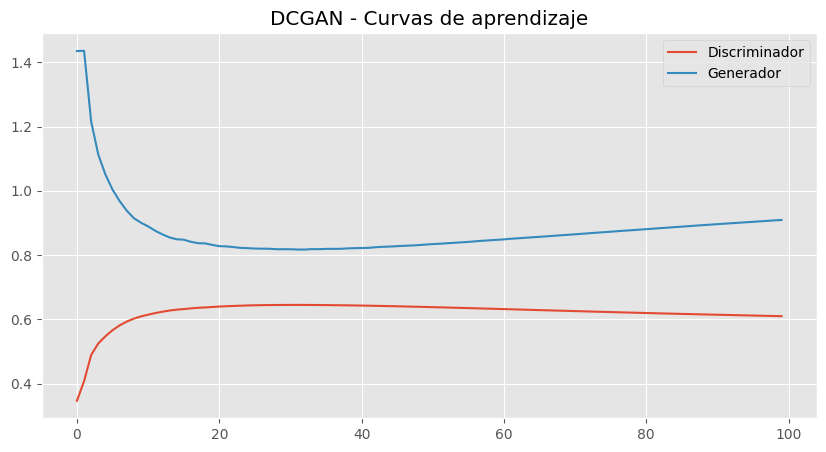

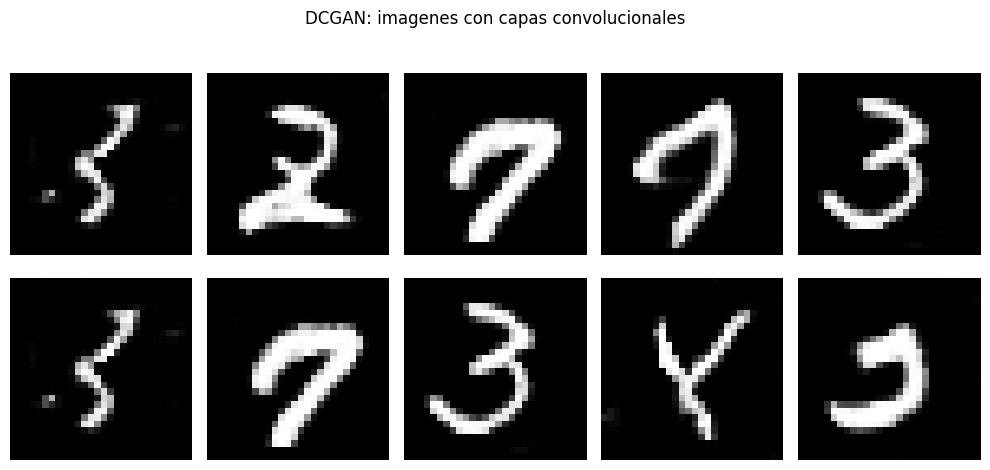

In [15]:
# Ejercicio 3: Capas convolucionales - DCGAN sobre MNIST
from keras.datasets import mnist
from keras.layers import (Input, Dense, Reshape, Flatten, BatchNormalization,
                           LeakyReLU, Conv2D, Conv2DTranspose)
from keras.models import Sequential
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Datos MNIST ---
(X_tr_dc, _), (_, _) = mnist.load_data()
X_tr_dc = X_tr_dc.astype(np.float32) / 255.0 * 2.0 - 1.0
X_tr_dc = np.expand_dims(X_tr_dc, -1)  # (60000, 28, 28, 1)
latent_dc = 100

# --- Generador: noise -> 7x7x128 -> 14x14x64 -> 28x28x1 ---
dcgen = Sequential(name='dcgan_generator')
dcgen.add(Input((latent_dc,)))
dcgen.add(Dense(7 * 7 * 128))
dcgen.add(Reshape((7, 7, 128)))
dcgen.add(BatchNormalization(momentum=0.8))
dcgen.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
dcgen.add(LeakyReLU(0.2))
dcgen.add(BatchNormalization(momentum=0.8))
dcgen.add(Conv2DTranspose(32, kernel_size=4, strides=2, padding='same'))
dcgen.add(LeakyReLU(0.2))
dcgen.add(BatchNormalization(momentum=0.8))
dcgen.add(Conv2D(1, kernel_size=3, padding='same', activation='tanh'))
dcgen.summary()

# --- Discriminador convolucional ---
dcdisc = Sequential(name='dcgan_discriminator')
dcdisc.add(Input((28, 28, 1)))
dcdisc.add(Conv2D(32,  kernel_size=3, strides=2, padding='same')); dcdisc.add(LeakyReLU(0.2))
dcdisc.add(Conv2D(64,  kernel_size=3, strides=2, padding='same')); dcdisc.add(LeakyReLU(0.2))
dcdisc.add(Conv2D(128, kernel_size=3, strides=1, padding='same')); dcdisc.add(LeakyReLU(0.2))
dcdisc.add(Flatten())
dcdisc.add(Dense(1, activation='sigmoid'))
dcdisc.summary()
dcdisc.compile(loss='binary_crossentropy',
               optimizer=Adam(2e-4, beta_1=0.5, weight_decay=8e-8),
               metrics=['accuracy'])

# --- Modelo combinado ---
dcdisc.trainable = False
dcgan = Sequential(name='dcgan_combined')
dcgan.add(dcgen); dcgan.add(dcdisc)
dcgan.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5, weight_decay=8e-8))
dcdisc.trainable = True

# --- Entrenamiento ---
n_tr_dc = 20000; ep_dc = 100; bs_dc = 128
DD_dc, GG_dc = [], []
ds_dc = tf.data.Dataset.from_tensor_slices(X_tr_dc).\
    shuffle(len(X_tr_dc), reshuffle_each_iteration=True).batch(bs_dc)
pb = tqdm(range(ep_dc), desc='Training DCGAN')
for epoch in pb:
    g_l, d_l, d_a = 0.0, 0.0, 0.0
    for x_real in ds_dc.take(n_tr_dc // bs_dc):
        bs = x_real.shape[0]
        x_fake = dcgen(tf.random.normal((bs, latent_dc)))
        xx = tf.concat([x_real, x_fake], axis=0)
        yy = tf.concat([tf.ones((bs,1)), tf.zeros((bs,1))], axis=0)
        dcdisc.trainable = True
        dm = dcdisc.train_on_batch(xx, yy)
        d_l += dm[0]; d_a += dm[1]
        dcdisc.trainable = False
        g_l += dcgan.train_on_batch(tf.random.normal((2*bs, latent_dc)), tf.ones((2*bs,1)))
    n_b = n_tr_dc // bs_dc
    d_l /= n_b; d_a /= n_b; g_l /= n_b
    pb.set_description(f'DCGAN gen={g_l:.4f} disc={d_l:.4f} acc={d_a:.4f}')
    DD_dc.append(d_l); GG_dc.append(g_l)

plt.plot(DD_dc, label='Discriminador'); plt.plot(GG_dc, label='Generador')
plt.legend(); plt.title('DCGAN - Curvas de aprendizaje'); plt.show()

imgs_dc = dcgen(np.random.normal(0,1,(10, latent_dc))).numpy()
for i in range(5):
    plt.subplot(2,5,i+1);   plt.imshow(imgs_dc[i,:,:,0],   cmap='gray'); plt.axis('off')
    plt.subplot(2,5,5+i+1); plt.imshow(imgs_dc[2*i,:,:,0], cmap='gray'); plt.axis('off')
plt.suptitle('DCGAN: imagenes con capas convolucionales'); plt.tight_layout(); plt.show()


### Ejercicio EXTRA:
Modifica el código para balancear cuanto aprende el generador y cuanto el discriminador.

Por ejemplo haz que el número de datos en el batch de entrenamiento dependa del coste (loss) en el paso de entrenamiento anterior de cada modelo (generador o discriminador). Es decir, si el discriminador aprende mucho (su loss es bajo) en el siguiente paso de entrenamiento le daré menos datos (para que aprenda menos).  

GAN Balanceo Dinamico:   0%|          | 0/100 [00:00<?, ?it/s]

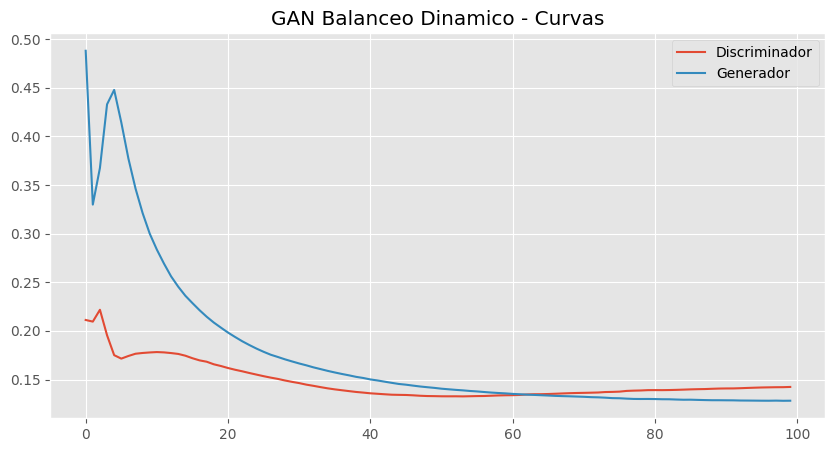

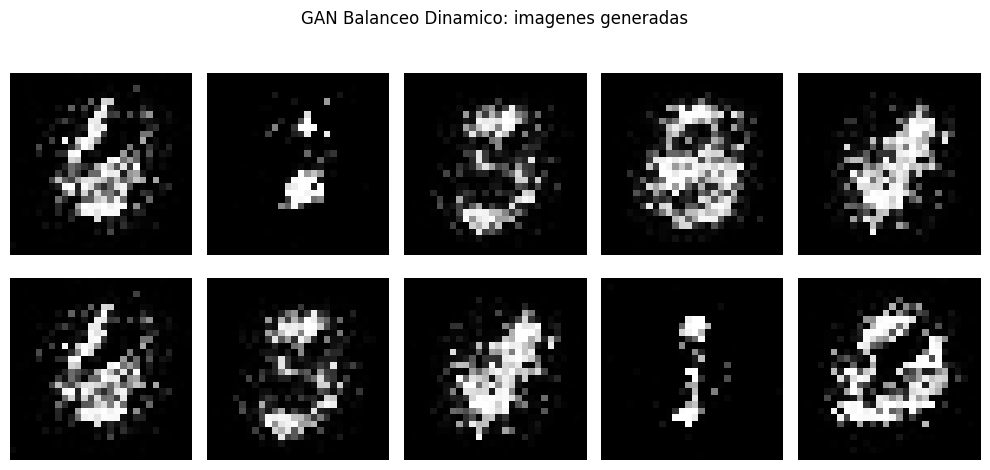

In [16]:
# Ejercicio EXTRA 1: Balanceo dinamico de entrenamiento segun loss previo
#
# Regla: si disc. tiene loss bajo (aprende mucho) => reduce sus batches.
# Se reparte como ratio = d_loss / (d_loss + g_loss), entre [0.2, 0.8].
# El discriminador recibe base_batches * ratio batches;
# el generador recibe base_batches * (1 - ratio).
from keras.datasets import mnist
from keras.layers import Input, Dense, Reshape, Flatten, BatchNormalization, LeakyReLU
from keras.models import Sequential
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Datos ---
(X_tr_ex, _), (_, _) = mnist.load_data()
X_tr_ex = X_tr_ex.astype(np.float32) / 255.0 * 2.0 - 1.0
X_tr_ex = np.expand_dims(X_tr_ex, -1)
in_sh_ex = X_tr_ex.shape[1:]; lat_ex = 100

# --- Modelos (misma arquitectura que el prelab) ---
gen_ex = Sequential(name='gen_ex1')
gen_ex.add(Input((lat_ex,)))
gen_ex.add(Dense(256));  gen_ex.add(LeakyReLU(0.2)); gen_ex.add(BatchNormalization(momentum=0.8))
gen_ex.add(Dense(512));  gen_ex.add(LeakyReLU(0.2)); gen_ex.add(BatchNormalization(momentum=0.8))
gen_ex.add(Dense(1024)); gen_ex.add(LeakyReLU(0.2)); gen_ex.add(BatchNormalization(momentum=0.8))
gen_ex.add(Dense(int(np.prod(in_sh_ex)), activation='tanh'))
gen_ex.add(Reshape(in_sh_ex))

dis_ex = Sequential(name='dis_ex1')
dis_ex.add(Input(in_sh_ex)); dis_ex.add(Flatten())
dis_ex.add(Dense(128)); dis_ex.add(LeakyReLU(0.2))
dis_ex.add(Dense(64));  dis_ex.add(LeakyReLU(0.2))
dis_ex.add(Dense(1, activation='sigmoid'))
dis_ex.compile(loss='binary_crossentropy',
               optimizer=Adam(2e-4, beta_1=0.5, weight_decay=8e-8), metrics=['accuracy'])

dis_ex.trainable = False
gan_ex = Sequential(name='gan_ex1')
gan_ex.add(gen_ex); gan_ex.add(dis_ex)
gan_ex.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5, weight_decay=8e-8))
dis_ex.trainable = True

# --- Entrenamiento con balanceo dinamico ---
n_samples_ex = 20000; ep_ex = 100; bs_ex = 128
base_batches = n_samples_ex // bs_ex
DD_ex, GG_ex = [], []
prev_d = 1.0; prev_g = 1.0

ds_ex = (tf.data.Dataset.from_tensor_slices(X_tr_ex)
         .shuffle(len(X_tr_ex), reshuffle_each_iteration=True)
         .batch(bs_ex).repeat())
it_ex = iter(ds_ex)

pb = tqdm(range(ep_ex), desc='GAN Balanceo Dinamico')
for epoch in pb:
    ratio   = float(np.clip(prev_d / (prev_d + prev_g + 1e-8), 0.2, 0.8))
    n_d_bat = max(1, int(base_batches * ratio))
    n_g_bat = max(1, int(base_batches * (1.0 - ratio)))
    g_l, d_l, d_a = 0.0, 0.0, 0.0

    # Entrenar discriminador n_d_bat batches
    dis_ex.trainable = True
    for _ in range(n_d_bat):
        xr = next(it_ex); b = xr.shape[0]
        xf = gen_ex(tf.random.normal((b, lat_ex)))
        dm = dis_ex.train_on_batch(
            tf.concat([xr, xf], 0), tf.concat([tf.ones((b,1)), tf.zeros((b,1))], 0))
        d_l += dm[0]; d_a += dm[1]
    d_l /= n_d_bat; d_a /= n_d_bat

    # Entrenar generador n_g_bat batches
    dis_ex.trainable = False
    for _ in range(n_g_bat):
        g_l += gan_ex.train_on_batch(tf.random.normal((bs_ex, lat_ex)), tf.ones((bs_ex,1)))
    g_l /= n_g_bat

    prev_d = d_l; prev_g = g_l
    pb.set_description(
        f'd_bat={n_d_bat} g_bat={n_g_bat} | gen={g_l:.4f} disc={d_l:.4f} acc={d_a:.4f}')
    DD_ex.append(d_l); GG_ex.append(g_l)

plt.plot(DD_ex, label='Discriminador'); plt.plot(GG_ex, label='Generador')
plt.legend(); plt.title('GAN Balanceo Dinamico - Curvas'); plt.show()

imgs_ex = gen_ex(np.random.normal(0,1,(10, lat_ex))).numpy()
for i in range(5):
    plt.subplot(2,5,i+1);   plt.imshow(imgs_ex[i,:,:,0],   cmap='gray'); plt.axis('off')
    plt.subplot(2,5,5+i+1); plt.imshow(imgs_ex[2*i,:,:,0], cmap='gray'); plt.axis('off')
plt.suptitle('GAN Balanceo Dinamico: imagenes generadas'); plt.tight_layout(); plt.show()


### Ejercicio EXTRA:
Crea un modelo que incluya todas las modificaciones de los cuatro ejercicios anteriores.

Model: "integrated_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_int           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_gen_int       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 110)       │          0 │ noise_int[0][0],  │
│ (Concatenate)       │                   │            │ label_gen_int[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 4096)      │    454,656 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 4, 4, 256) │          0 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 256) │      1,024 │ reshape_5[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 8, 8, 128) │    524,416 │ batch_normalizat… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_25      │ (None, 8, 8, 128) │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ leaky_re_lu_25[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 16, 16,    │    131,136 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_26      │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ leaky_re_lu_26[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │     32,800 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_27      │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ leaky_re_lu_27[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32, 3) │        867 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,145,795 (4.37 MB)

 Trainable params: 1,144,835 (4.37 MB)

 Non-trainable params: 960 (3.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_disc_int      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 10240)     │    112,640 │ label_disc_int[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_int           │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 32, 32,    │          0 │ dense_31[0][0]    │
│                     │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ image_int[0][0],  │
│ (Concatenate)       │ 13)               │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      7,552 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ leaky_re_lu_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 8, 8, 128) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ leaky_re_lu_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_30      │ (None, 4, 4, 256) │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4096)      │          0 │ leaky_re_lu_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │      4,097 │ flatten_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 493,313 (1.88 MB)

 Trainable params: 493,313 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

GAN Integrado:   0%|          | 0/50 [00:00<?, ?it/s]

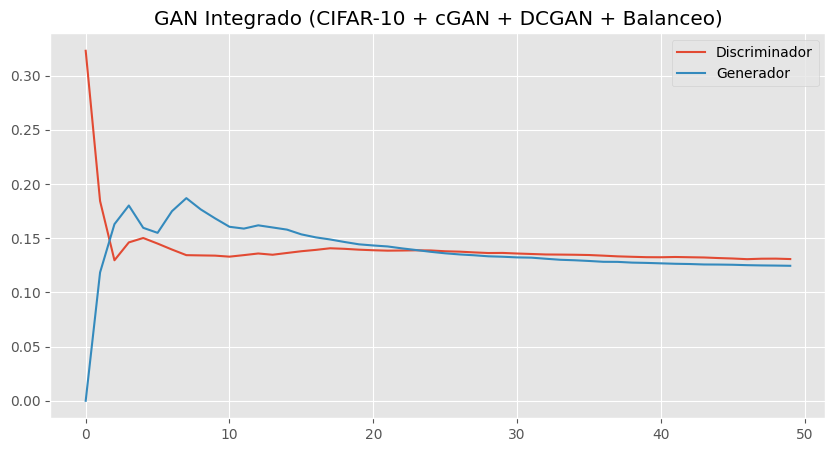

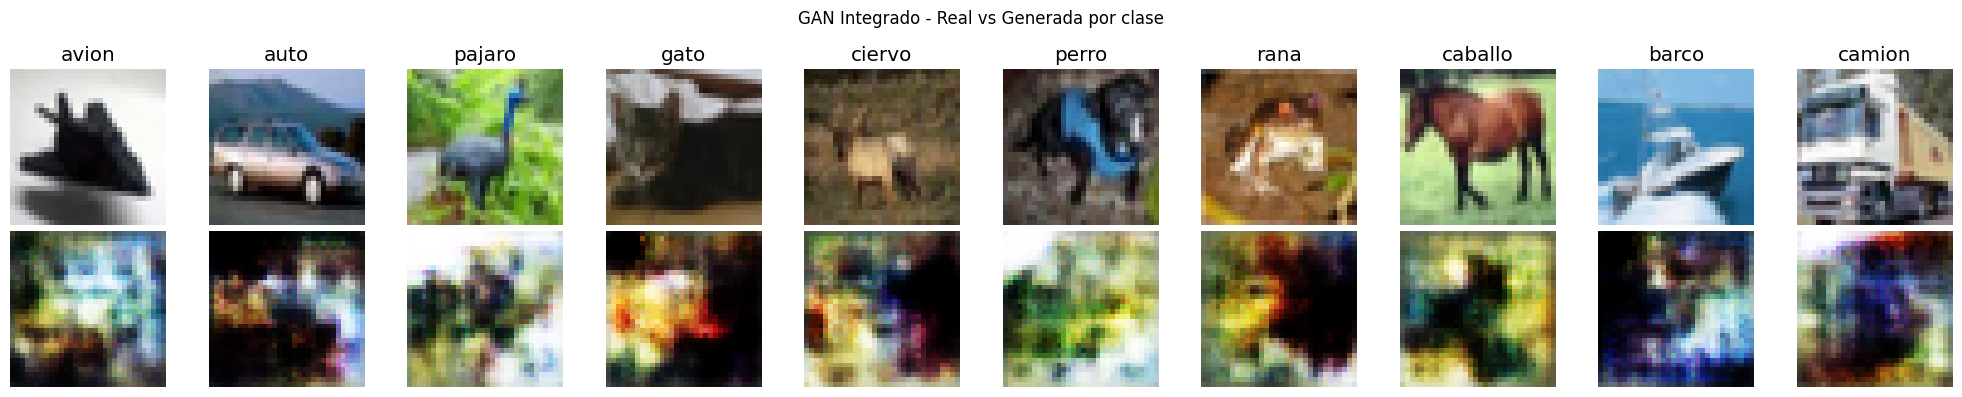

In [17]:
# Ejercicio EXTRA 2: Modelo integrado
# Combina: CIFAR-10 + etiquetas (cGAN) + capas convolucionales (DCGAN) + balanceo dinamico
from keras.datasets import cifar10
from keras.layers import (Input, Dense, Reshape, Flatten, BatchNormalization,
                           LeakyReLU, Conv2D, Conv2DTranspose, Concatenate)
from keras.models import Model
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Parametros ---
latent_int = 100; num_cls = 10; img_sh_int = (32, 32, 3)
class_names = ['avion','auto','pajaro','gato','ciervo',
               'perro','rana','caballo','barco','camion']

# --- Datos CIFAR-10 con etiquetas ---
(X_int, y_int_raw), (_, _) = cifar10.load_data()
y_int = y_int_raw.flatten()
X_int = X_int.astype(np.float32) / 255.0 * 2.0 - 1.0
y_hot_int = np.eye(num_cls)[y_int]  # (50000, 10)

# --- Generador convolucional condicional ---
# noise (100,) + etiqueta (10,) => imagen (32,32,3)
noise_i = Input(shape=(latent_int,), name='noise_int')
label_i = Input(shape=(num_cls,), name='label_gen_int')
x = Concatenate()([noise_i, label_i])
x = Dense(4 * 4 * 256, activation='relu')(x)
x = Reshape((4, 4, 256))(x)
x = BatchNormalization(momentum=0.8)(x)
x = Conv2DTranspose(128, 4, strides=2, padding='same')(x)  # 8x8
x = LeakyReLU(0.2)(x); x = BatchNormalization(momentum=0.8)(x)
x = Conv2DTranspose(64, 4, strides=2, padding='same')(x)   # 16x16
x = LeakyReLU(0.2)(x); x = BatchNormalization(momentum=0.8)(x)
x = Conv2DTranspose(32, 4, strides=2, padding='same')(x)   # 32x32
x = LeakyReLU(0.2)(x); x = BatchNormalization(momentum=0.8)(x)
x = Conv2D(3, 3, padding='same', activation='tanh')(x)     # 32x32x3
int_gen = Model([noise_i, label_i], x, name='integrated_generator')
int_gen.summary()

# --- Discriminador convolucional condicional ---
# La etiqueta se proyecta a un mapa espacial (32,32,10) y se concatena con la imagen
img_i   = Input(shape=img_sh_int, name='image_int')
label_d = Input(shape=(num_cls,), name='label_disc_int')
lmap = Dense(32*32*num_cls)(label_d)
lmap = Reshape((32, 32, num_cls))(lmap)
xd = Concatenate()([img_i, lmap])              # (32,32,13)
xd = Conv2D(64,  3, strides=2, padding='same')(xd); xd = LeakyReLU(0.2)(xd)  # 16x16
xd = Conv2D(128, 3, strides=2, padding='same')(xd); xd = LeakyReLU(0.2)(xd)  # 8x8
xd = Conv2D(256, 3, strides=2, padding='same')(xd); xd = LeakyReLU(0.2)(xd)  # 4x4
xd = Flatten()(xd)
xd = Dense(1, activation='sigmoid')(xd)
int_disc = Model([img_i, label_d], xd, name='integrated_discriminator')
int_disc.summary()
int_disc.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5), metrics=['accuracy'])

# --- Modelo combinado ---
int_disc.trainable = False
n_in = Input(shape=(latent_int,)); l_in = Input(shape=(num_cls,))
int_combined = Model([n_in, l_in],
                     int_disc([int_gen([n_in, l_in]), l_in]),
                     name='integrated_gan')
int_combined.compile(loss='binary_crossentropy', optimizer=Adam(2e-4, beta_1=0.5))
int_disc.trainable = True

# --- Entrenamiento con balanceo dinamico ---
n_sam_int = 10000; ep_int = 50; bs_int = 64
base_bat_int = n_sam_int // bs_int
DD_int, GG_int = [], []
prev_di, prev_gi = 1.0, 1.0

pb = tqdm(range(ep_int), desc='GAN Integrado')
for epoch in pb:
    ratio_i  = float(np.clip(prev_di / (prev_di + prev_gi + 1e-8), 0.2, 0.8))
    n_d_i    = max(1, int(base_bat_int * ratio_i))
    n_g_i    = max(1, int(base_bat_int * (1.0 - ratio_i)))
    g_li, d_li, d_ai = 0.0, 0.0, 0.0

    int_disc.trainable = True
    for _ in range(n_d_i):
        idx = np.random.choice(len(X_int), bs_int, replace=False)
        xr = X_int[idx]; lr = y_hot_int[idx]
        lf = np.eye(num_cls)[np.random.randint(0, num_cls, bs_int)]
        xf = int_gen.predict([np.random.normal(0,1,(bs_int, latent_int)), lf], verbose=0)
        dr = int_disc.train_on_batch([xr, lr], np.ones((bs_int,1)))
        df = int_disc.train_on_batch([xf, lf], np.zeros((bs_int,1)))
        d_li += 0.5*(dr[0]+df[0]); d_ai += 0.5*(dr[1]+df[1])
    d_li /= n_d_i; d_ai /= n_d_i

    int_disc.trainable = False
    for _ in range(n_g_i):
        n_v = np.random.normal(0,1,(bs_int, latent_int))
        l_v = np.eye(num_cls)[np.random.randint(0, num_cls, bs_int)]
        g_li += int_combined.train_on_batch([n_v, l_v], np.ones((bs_int,1)))
    g_li /= n_g_i

    prev_di = d_li; prev_gi = g_li
    pb.set_description(f'd={n_d_i} g={n_g_i} | gen={g_li:.4f} disc={d_li:.4f} acc={d_ai:.4f}')
    DD_int.append(d_li); GG_int.append(g_li)

plt.plot(DD_int, label='Discriminador'); plt.plot(GG_int, label='Generador')
plt.legend(); plt.title('GAN Integrado (CIFAR-10 + cGAN + DCGAN + Balanceo)'); plt.show()

# Visualizar: real vs generada por clase
fig, axes = plt.subplots(2, num_cls, figsize=(20, 4))
for i in range(num_cls):
    n_v = np.random.normal(0,1,(1, latent_int)); l_v = np.eye(num_cls)[[i]]
    img_gen = int_gen.predict([n_v, l_v], verbose=0)[0]
    img_gen = (img_gen + 1.0) / 2.0
    idx_real = np.where(y_int == i)[0][0]
    img_real = (X_int[idx_real] + 1.0) / 2.0
    axes[0, i].imshow(img_real); axes[0, i].set_title(class_names[i]); axes[0, i].axis('off')
    axes[1, i].imshow(img_gen);  axes[1, i].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=10)
axes[1, 0].set_ylabel('Generada', fontsize=10)
plt.suptitle('GAN Integrado - Real vs Generada por clase'); plt.tight_layout(); plt.show()
